# First Linear Regression Model
## Predicting Total Spent — Café Sales Dataset

## 1. Import Libraries
Importing all necessary libraries for data manipulation,
preprocessing, modeling and evaluation.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## 2. Load Dataset

In [93]:
df = pd.read_csv("/content/cleaned_cafe_sales.csv")

## 3. Data Exploration

In [94]:
df.shape

(9517, 9)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9517 entries, 0 to 9516
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    9517 non-null   object 
 1   Item              9517 non-null   object 
 2   Quantity          9517 non-null   float64
 3   Price Per Unit    9517 non-null   float64
 4   Total Spent       9517 non-null   float64
 5   Payment Method    9517 non-null   object 
 6   Location          9517 non-null   object 
 7   Transaction Date  9517 non-null   object 
 8   Month             9517 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 669.3+ KB


In [96]:
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0
Month,0


In [97]:
df.sample(15)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month
6246,TXN_3251340,Salad,4.000000,5.0,20.000000,Cash,In-store,2023-06-18,6
5267,TXN_6413250,Salad,3.006601,5.0,15.033003,Cash,In-store,2023-12-02,12
7425,TXN_7445257,Coffee,1.000000,2.0,2.000000,Digital Wallet,Takeaway,2023-04-02,4
9047,TXN_8272750,Salad,5.000000,5.0,25.000000,Cash,In-store,2023-05-18,5
3101,TXN_2477550,Smoothie,2.000000,4.0,8.000000,Cash,Takeaway,2023-02-02,2
4268,TXN_8120958,Cookie,5.000000,1.0,5.000000,Credit Card,Takeaway,2023-06-21,6
5086,TXN_4315166,Sandwich,2.000000,4.0,8.000000,Digital Wallet,Takeaway,2023-06-10,6
5615,TXN_3919672,Cookie,2.973090,1.0,2.973090,Credit Card,Takeaway,2023-11-05,11
7984,TXN_2749862,Salad,4.000000,5.0,20.000000,Digital Wallet,In-store,2023-07-19,7
5633,TXN_2721997,Cake,3.000000,3.0,9.000000,Cash,Takeaway,2023-05-20,5


In [98]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'Digital Wallet'], dtype=object)

In [99]:
df["Location"].unique()

array(['Takeaway', 'In-store'], dtype=object)

## 4. Encoding Categorical Variables

In [100]:
df = pd.get_dummies(df, columns=["Payment Method", "Location", "Item"], drop_first=True)


In [101]:
df.sample(15)

,Transaction ID,Quantity,Price Per Unit,Total Spent,Transaction Date,Month,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea
6423,TXN_2556368,1.0,4.0,4.0,2023-10-26,10,False,True,False,False,False,False,False,False,True,False
3169,TXN_8993132,3.0,3.0,9.0,2023-01-21,1,False,False,False,False,False,False,False,False,False,False
7429,TXN_5575420,3.0,4.0,12.0,2023-06-26,6,True,False,False,False,False,False,False,False,True,False
5629,TXN_9928409,4.0,4.0,16.0,2023-06-17,6,True,False,False,False,False,False,False,True,False,False
2922,TXN_1229376,3.0,3.0,9.0,2023-08-14,8,False,True,False,False,False,False,False,False,False,False
600,TXN_5933480,3.0,4.0,12.0,2023-09-04,9,False,True,False,False,False,False,False,True,False,False
5218,TXN_8839045,2.0,3.0,6.0,2023-06-13,6,False,False,False,False,False,False,False,False,False,False
4678,TXN_4028494,3.0,3.0,9.0,2023-10-22,10,False,True,False,False,False,False,False,False,False,False
1074,TXN_6829707,1.0,4.0,4.0,2023-08-17,8,False,False,True,False,False,False,False,True,False,False
1727,TXN_6568536,1.0,3.0,3.0,2023-12-29,12,False,False,True,False,False,False,False,False,False,False


## 5. Define Features and Target

In [102]:
X = df.drop(columns=["Total Spent", "Transaction ID", "Transaction Date"])
y = df["Total Spent"]

In [103]:
X

,Quantity,Price Per Unit,Month,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea
0,2.0,2.0,9,True,False,True,True,False,False,False,False,False,False
1,4.0,3.0,5,False,False,False,False,False,False,False,False,False,False
2,4.0,1.0,7,True,False,False,False,True,False,False,False,False,False
3,2.0,5.0,4,False,False,False,False,False,False,True,False,False,False
4,2.0,2.0,6,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9512,4.0,4.0,1,True,False,False,False,False,False,False,False,True,False
9513,2.0,2.0,8,False,True,True,True,False,False,False,False,False,False
9514,4.0,2.0,3,False,True,True,True,False,False,False,False,False,False
9515,3.0,1.0,12,False,True,True,False,True,False,False,False,False,False


In [104]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Month
count,9517.000000,9517.000000,9517.000000,9517.000000
mean,3.024130,2.947568,8.922954,6.524010
std,1.384332,1.278740,5.916714,3.449262
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,4.000000,4.000000
50%,3.000000,3.000000,8.000000,7.000000
75%,4.000000,4.000000,12.000000,10.000000
max,5.000000,5.000000,25.000000,12.000000


In [105]:
y

,Total Spent
0,4.0
1,12.0
2,4.0
3,10.0
4,4.0
...,...
9512,16.0
9513,4.0
9514,8.0
9515,3.0


## 6. Train/Test Split

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [107]:
print(f"the shape of training input is {X_train.shape}")
print(f"the shape of training output is {y_train.shape}")
print(f"the shape of testing input is {X_test.shape}")
print(f"the shape of testing output is {y_test.shape}")

the shape of training input is (7613, 13)
the shape of training output is (7613,)
the shape of testing input is (1904, 13)
the shape of testing output is (1904,)


## 7. Feature Scaling

In [108]:
scaler = RobustScaler()
X_train[["Quantity", "Price Per Unit"]] = scaler.fit_transform(
    X_train[["Quantity", "Price Per Unit"]]
)
X_test[["Quantity", "Price Per Unit"]] = scaler.transform(
    X_test[["Quantity", "Price Per Unit"]]
)

In [109]:
X_train

,Quantity,Price Per Unit,Month,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Takeaway,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea
7433,-1.0,-0.5,2,False,True,True,True,False,False,False,False,False,False
5296,-1.0,-0.5,4,False,False,True,True,False,False,False,False,False,False
5646,0.0,-1.0,1,False,False,True,False,True,False,False,False,False,False
2954,-0.5,-1.0,4,True,False,False,False,True,False,False,False,False,False
3017,0.0,-1.0,9,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,-1.0,-1.0,7,False,True,False,False,True,False,False,False,False,False
5191,-0.5,1.0,10,False,True,True,False,False,False,True,False,False,False
5390,0.0,0.0,12,False,True,True,False,False,True,False,False,False,False
860,0.0,-1.0,12,True,False,True,False,True,False,False,False,False,False


## 8. Model Training

In [110]:
model = LinearRegression()

In [111]:
model.fit(X_train, y_train)

LinearRegression()

In [112]:
y_pred = model.predict(X_test)

## 9. Visualization — Actual vs Predicted

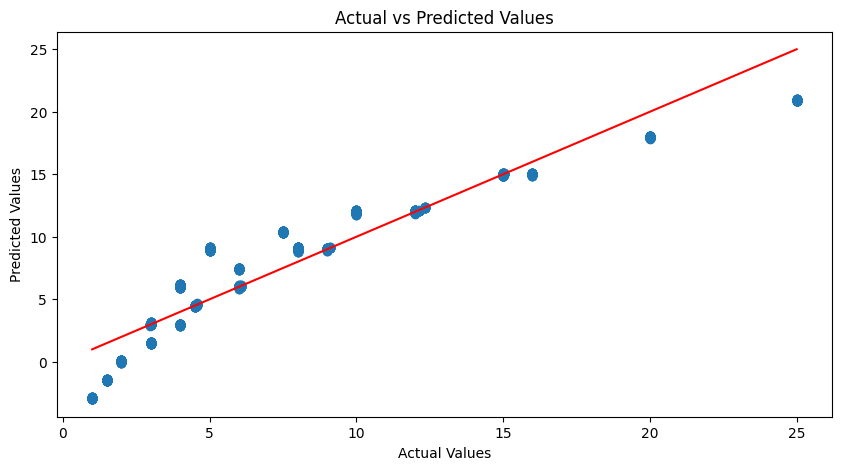

In [113]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

## 10. Model Evaluation

In [114]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9119614154989362
MAE: 1.2072314261146748


## 11. Conclusion

**R² Score: 0.91** — The model explains 91% of the variance in Total Spent.

**MAE: 1.21** — On average predictions are off by 1.21.

The high R² score is expected because Total Spent has a near perfect
linear relationship with Quantity and Price Per Unit
(Total Spent ≈ Quantity × Price Per Unit).

This project demonstrates a complete ML pipeline:
data loading → exploration → encoding → splitting → scaling → training → evaluation